# Сборка датасета (TRAIN_DATA.csv)

**Cтартовая точка** — `TRAIN_DATA.csv` (ее краткое описание ниже).
В этом ноутбуке показана вся работа над данными: сначала улучшение разметки (версии v2, v3, отбор лучших версий, active-learning батчи, набор T3), 
затем обогащение датасета реальными примерами
из нового пула (~1 млн сообщений) и сборка итогового `TRAIN_DATA_v6`:

1. переход к 4 классам;
2. запрос дополнительных данных 
3. майнинг реальных примеров редких классов из этого пула;
4. ручная разметка отобранных кандидатов;
5. добавление реалистичных синтетических угроз;
6. сборка итогового датасета


In [ ]:
import re
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams["figure.dpi"] = 110
COLORS = ["#1C7293", "#E07A5F", "#0E7C86", "#B85042"]

## 1. Стартовая точка: `TRAIN_DATA.csv`

Что на старте. Колонка `synthetic` показывает, реальное это сообщение (0) или
синтетика (1). Сразу видно главную проблему: редкие классы (`threat`, `harassment`)
почти целиком синтетические.

In [3]:
train0 = pd.read_csv("TRAIN_DATA.csv")
val0   = pd.read_csv("VAL_DATA.csv")
print("TRAIN_DATA.csv:", train0.shape, "| VAL_DATA.csv:", val0.shape)
print(train0.groupby(["sentiment", "synthetic"]).size())

TRAIN_DATA.csv: (17986, 5) | VAL_DATA.csv: (10420, 5)
sentiment   synthetic
external    0            2163
            1            3675
harassment  0              43
            1            1653
normal      0            8000
spam        0             110
            1            1878
threat      0               2
            1             462
dtype: int64


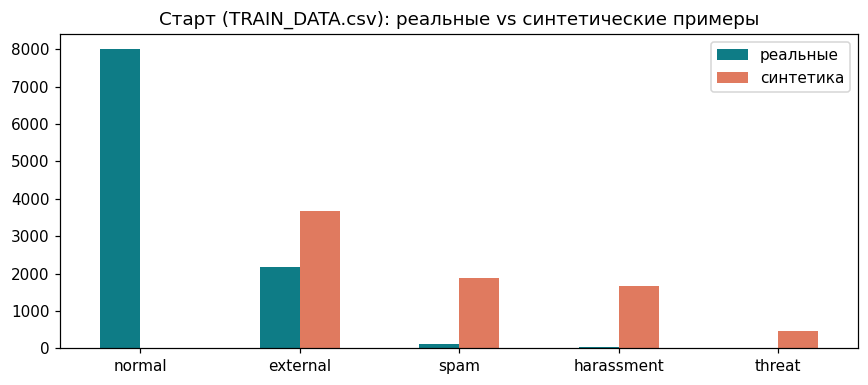

Реальных threat: 2 | реальных harassment: 43


In [ ]:
# сколько РЕАЛЬНЫХ примеров в каждом классе на старте
real = train0[train0["synthetic"] == 0]["sentiment"].value_counts()
synt = train0[train0["synthetic"] == 1]["sentiment"].value_counts()
order = ["normal", "external", "spam", "harassment", "threat"]

ax = pd.DataFrame({"реальные": real, "синтетика": synt}).reindex(order).plot(kind="bar", figsize=(8, 3.6))
ax.set_title("Старт (TRAIN_DATA.csv): реальные vs синтетические примеры")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("Реальных threat:", int(real.get("threat", 0)), "| реальных harassment:", int(real.get("harassment", 0)))

**Вывод:** реальных `threat` -- единицы, реальных `harassment` -- несколько десятков.
Модель на такой синтетике плохо обобщается. Значит, нужны **настоящие** примеры редких
классов.

## 2. Улучшение разметки датасета

Над `TRAIN_DATA.csv` было выполнено несколько итераций расширения по проблемным классам.
Исходный набор собран ручной разметкой с эвристиками (регулярки на телефоны, мессенджеры,
мат) и LLM-аугментацией (GigaChat). Далее проводилось:

- **`TRAIN_DATA_v2` — расширение harassment** четырьмя способами: мат-инъекция живых фраз
  (словарь `bars38`, лёгкая обфускация), фильтрация токсичных корпусов `AlexSham` и
  `ru_paradetox`, отдельный набор «оскорбление + мессенджер» (против путаницы с external).
- **`TRAIN_DATA_v3` — расширение spam**: сбор рекламы без контактов (промо-маркеры с
  отсевом телефонов/ссылок) и шаблонная генерация авито-промо, чтобы развести «реклама без
  контакта = spam» и «реклама с контактом = external», позже версия разделения этих классов была отвергнута в силы гипотезы, что реальный спам следует отделять частотой однотипно отправленных сообщений конкретнй=ой группой пользователя, а не содержанием самого текста.
- **Отбор версий**: проверка показала, что мат-инъекция шумит -> 
- создана версия `v2_no_A`.
  v2_no_A — это версия расширения harassment без способа A (мат-инъекции). В ablation выяснилось, что искусственная вставка мата в обычные сообщения звучит неестественно и шумит модель. Поэтому из v2 убрали именно A-строки, оставив полезные добавки: реальные токсичные корпуса (AlexSham, ru_paradetox) и «оскорбление+мессенджер». harassment при этом 1696 → 2269. Назначение: это лучшая база для дообучения BERT — на ней fine-tune ruBERT-tiny2 давал заметно выше качество (macro_f1 ≈ 0.69 против ≈ 0.65 на полной v2) ->
- создана версия `v2_no_A_all_spam_top100`.
  Логика: полная spam-добавка из v3 шумит, но внутри неё есть полезное ядро живого спама. Поэтому каждую spam-добавку оценили вспомогательной char-SVM-моделью и взяли только топ-100 по «спамовости» (spam 1988 → 2088). Назначение: это лучшая версия для линейной char/TF-IDF + SVM/LogReg модели — на ней она давала небольшой, но прирост (macro_f1 0.741 → 0.742). При этом для BERT она НЕ годилась (fine-tune на ней проседал).
- **Active-learning батчи `001…005`**: ручная разметка трудных реальных сообщений (спорные
  spam/external, harassment без мата, угрозы) небольшими партиями.

## 2.1. Отбор кандидатов active learning
Идея active learning — размечать не случайные сообщения, а самые «непонятные» модели, потому что они информативнее всего. Конвейер был такой:

- Источник — большой неразмеченный реальный корпус (messages_project_aaa.csv, ~492k сообщений).
Из него убирались точные пересечения с TRAIN и VAL (по text-hash), дубли, битая кодировка и шаблонный мусор.
- Оставшиеся прогонялись текущей моделью-лидером (char+title TF-IDF + LinearSVC), и в батч отбирались спорные случаи: низкий margin (модель не уверена), несогласие классификаторов между собой, предсказание редкого класса. 
- Целенаправленно брались именно проблемные границы: spam↔external, normal↔external, harassment↔normal, threat↔harassment.
- Эти кандидаты размечались вручную небольшими партиями (batch_001 ≈ 30, дальше больше), по согласованным правилам границ классов.

In [ ]:
# Баланс классов по ключевым версиям датасета
versions = [
    ("TRAIN_DATA.csv", "старт"),
    ("TRAIN_DATA_v2.csv", "v2: +harassment"),
    ("TRAIN_DATA_v3.csv", "v3: +spam"),
    ("TRAIN_DATA_v2_no_A.csv", "v2_no_A: отбор"),
]
dist = {}
for f, name in versions:
    if os.path.exists(f):
        dist[name] = pd.read_csv(f)["sentiment"].value_counts()
dist = pd.DataFrame(dist).fillna(0).astype(int)
print(dist)

            старт  v2: +harassment  v3: +spam  v2_no_A: отбор
sentiment                                                    
external     5838             5838       5838            5838
harassment   1696             2669       2669            2269
normal       8000             8000       8000            8000
spam         1988             1988       2598            1988
threat        464              464        464             464


**Ручная разметка active-learning батчей.** Размеченные партии лежат отдельными
файлами — ниже их объём и состав по классам.

Всего размечено вручную в этих батчах: 376
            batch_001  batch_002  batch_003  batch_005
external            0         13          5         20
harassment          6          4          7         70
normal             13         35         40         30
spam                8         26         33         40
threat              2          0          0         21
мусор               1          2          0          0


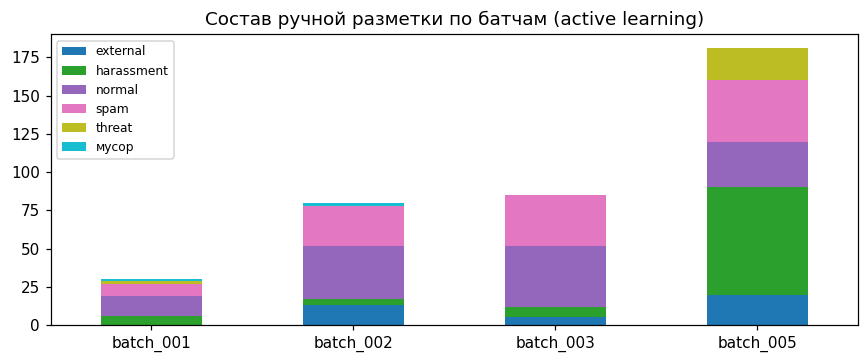

In [ ]:
batch_files = {
    "batch_001": "outputs/active_learning_batch_001/batch_001_labeled.csv",
    "batch_002": "outputs/active_learning_batch_002/batch_002_labeled.csv",
    "batch_003": "outputs/active_learning_batch_003/batch_003_labeled.csv",
    "batch_005": "outputs_new/batch_005/batch_005_labeled.csv",
}
comp = {}
for name, f in batch_files.items():
    if os.path.exists(f):
        d = pd.read_csv(f)
        col = "sentiment" if "sentiment" in d.columns else "label"
        comp[name] = d[col].value_counts()
comp = pd.DataFrame(comp).fillna(0).astype(int)
print("Всего размечено вручную в этих батчах:", int(comp.values.sum()))
print(comp)
ax = comp.T.plot(kind="bar", stacked=True, figsize=(8, 3.4), colormap="tab10")
ax.set_title("Состав ручной разметки по батчам (active learning)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Объём редких классов наращивался, но в основном **синтетикой**, и её потолок уже
достигнут. Поэтому следующий шаг — добавить именно **реальные** примеры. Дальше работа
снова идёт с обогащением живыми сообщениями из нового пула.

## 3. Проверка на даталик

Перед любыми экспериментами выполняется проверка: обучающие сообщения не пересекаются с
валидацией (иначе метрики завышены). Сравнение идёт по нормализованному тексту. Параллельно
5 классов сводятся к 4: `spam` объединяется с `external`.

In [ ]:
def norm_hash(t):
    return hashlib.md5(re.sub(r"\s+", " ", str(t).lower().strip()).encode()).hexdigest()

train0["_h"] = train0["text"].map(norm_hash)
val_hashes = set(val0["text"].map(norm_hash))
leak_mask = train0["_h"].isin(val_hashes)

# убираем утечку и внутренние дубли
base = train0[~leak_mask].drop_duplicates("_h").copy()

# 5 -> 4 класса
to4 = {"spam": "external"}
base["label4"] = base["sentiment"].replace(to4)
val0["label4"] = val0["sentiment"].replace(to4)
seen_hashes = set(base["_h"]) | val_hashes

## 4. Запросили дополнительные данные — csv на ~90 МБ

Чтобы получить реальные редкие классы, был запрошен дополнительный набор живых сообщений —
**`new_df_messages.csv`** (~90 МБ, около 1 млн строк, **без меток** — одна колонка `text`).
Ниже — его профиль.

In [10]:
pool = pd.read_csv("new_df_messages.csv")
pool = pool.dropna(subset=["text"])
pool["text"] = pool["text"].astype(str)
print("Сообщений в пуле:", len(pool))
print(pool["text"].head(6).tolist())

Сообщений в пуле: 999963
['Можно', 'Здравствуйте', 'Ну что, завтра получится встретиться?', 'В часов 11-12 дня и по какому адресу?', 'Отлично', 'Сдэком по полной предоплате']


## 5. Regex по новому пулу

Реджексом из пула извлекаются кандидаты в `external` (контакты/мессенджеры),
`harassment` (мат по словарю) и `threat` (прямые угрозы), так как дефицит этих классов исходя из метрик моделей все еще актуален. Короткие сообщения отбрасываем,
**кроме** тех, где есть мат или угроза. Дедуп против train и val обязателен.

/var/folders/np/msrgt0mj77nbg0k84zztkfvr0000gn/T/ipykernel_41403/2932227249.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_contact = pool["text"].str.contains(CONTACT)
/var/folders/np/msrgt0mj77nbg0k84zztkfvr0000gn/T/ipykernel_41403/2932227249.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_obscene = low.str.contains(OBSCENE)
/var/folders/np/msrgt0mj77nbg0k84zztkfvr0000gn/T/ipykernel_41403/2932227249.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_threat  = low.str.contains(THREAT)


Кандидатов найдено: {'external (контакты)': 11244, 'harassment (мат)': 1007, 'threat (угрозы-regex)': 614}


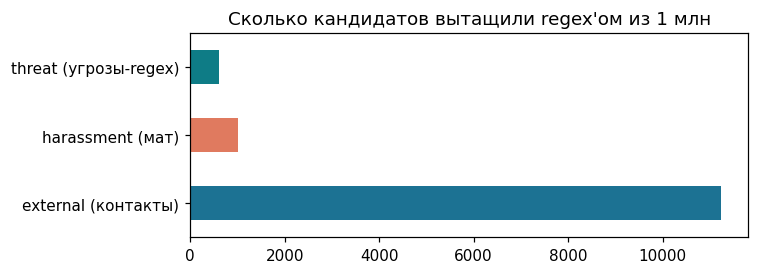

In [ ]:
CONTACT = re.compile(r"(@[\w_]{5,}|t\.me/|telegram|телеграм|телега\b|whatsap|ватсап|"
                     r"ватцап|вотсап|viber|вайбер|вконтакте|skype|(?:https?://|www\.)|"
                     r"(?<!\d)(?:\+7|8)\d{9,10}(?!\d))", re.I)
OBSCENE = re.compile(r"(бля|пизд|хуй|хуе|хуё|хуя|нахуй|похуй|муда|долбо[её]б|гандон|шлюх|"
                     r"ебать|ебал|ебан|ебуч|заеб|наеб|уеб|выеб|чмо\b|тварь|урод|дебил)", re.I)
THREAT  = re.compile(r"(расстрел|пристрел|застрел|убью|зарежу|прирежу|сожгу|спалю|подожгу|"
                     r"на кол|кастрир|изнасил|придуш|удавлю|перелома|оторв|башку|кишки)", re.I)

low = pool["text"].str.lower()
is_contact = pool["text"].str.contains(CONTACT)
is_obscene = low.str.contains(OBSCENE)
is_threat  = low.str.contains(THREAT)
too_short  = pool["text"].str.len() < 15

cand = {
    "external (контакты)":   int((is_contact & ~too_short).sum()),
    "harassment (мат)":      int(is_obscene.sum()),
    "threat (угрозы-regex)": int(is_threat.sum()),
}
print("Кандидатов найдено:", cand)
ax = pd.Series(cand).plot(kind="barh", figsize=(7, 2.6), color=COLORS)
ax.set_title("Сколько кандидатов вытащили regex'ом из 1 млн")
plt.tight_layout()
plt.show()

## 6. Ручная разметка кандидатов

regex только **отбирает** кандидатов — финальные метки между threat и harassment проставлялись **вручную**, по правилам разметки, так как для редких классов качество крайне важно. Результат разметки сохранён в `data_v6/batch_real_v6.csv`.

Размечено вручную: 1564 сообщений


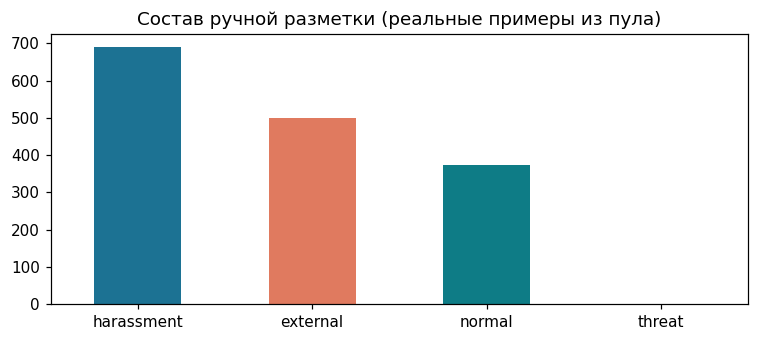

sentiment
harassment    690
external      500
normal        373
threat          1
Name: count, dtype: int64


In [ ]:
batch = pd.read_csv("data_v6/batch_real_v6.csv")
print("Размечено вручную:", len(batch), "сообщений")
ax = batch["sentiment"].value_counts().plot(kind="bar", figsize=(7, 3.2), color=COLORS)
ax.set_title("Состав ручной разметки (реальные примеры из пула)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(batch["sentiment"].value_counts())

Отдельно важно: реальных **threat** в живой переписке почти нет — regex по угрозам
давал в основном ложные срабатывания («зарезервирован», «кастрирован», «похороны»). Это
честное наблюдение: класс `threat` придётся подкреплять синтетикой.

## 7. Реалистичные синтетические угрозы

Раз реальных угроз нет, добавим еще **64** реалистичные самописные угрозы в стиле авито
(адресные угрозы продавцу/покупателю). Они помечены `synthetic=1` и лежат в
`data_v6/synthetic_threats_v6.csv`.

In [14]:
threats = pd.read_csv("data_v6/synthetic_threats_v6.csv")
print("Синтетических угроз:", len(threats))
for t in threats["text"].head(4):
    print(" •", t)

Синтетических угроз: 64
 • Не вернёшь деньги — приеду по адресу и ноги тебе переломаю
 • Кинул меня на оплате, найду тебя и закопаю
 • Ещё раз так напишешь — голову оторву, понял?
 • Не отправишь товар — спалю тебе машину под окнами


## 8. Сборка итогового `TRAIN_DATA_v6.csv`

Объединяются: очищенный старт и реальная ручная разметка. Ещё раз проверяется дата-лик
против валидации и убираются дубли.

In [ ]:
b = batch.copy()
b["label4"] = b["sentiment"].replace(to4)
cols = ["text", "item_title", "sentiment", "synthetic", "label4"]
for df in (base, b):
    for c in cols:
        if c not in df.columns:
            df[c] = "" if c == "item_title" else df.get(c)

v6 = pd.concat([base[cols], b[cols]], ignore_index=True)
v6["_h"] = v6["text"].map(norm_hash)
before = len(v6)
v6 = v6[~v6["_h"].isin(val_hashes)].drop_duplicates("_h").drop(columns="_h")
print("TRAIN_DATA_v6:", before, "->", len(v6), "(убрали лики/дубли)")
print(v6["label4"].value_counts())

TRAIN_DATA_v6: 19530 -> 19530 (убрали лики/дубли)
label4
normal        8368
external      8311
harassment    2386
threat         465
Name: count, dtype: int64


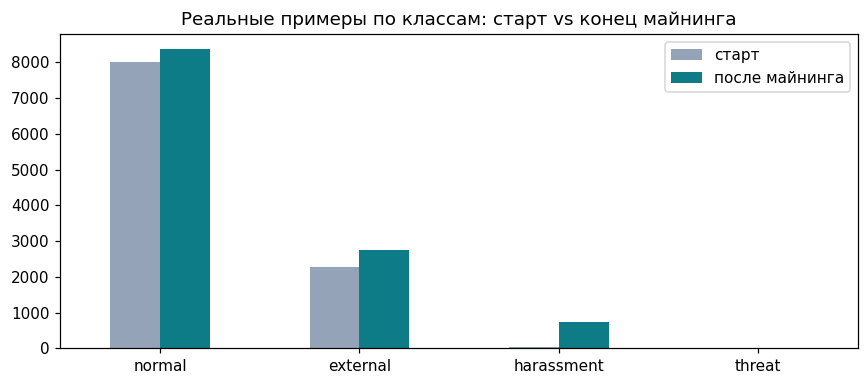

            старт  после майнинга
label4                           
normal       7995            8368
external     2263            2763
harassment     43             733
threat          2               3


In [ ]:
# сравнение реальных примеров: было (старт) -> стало (v6, без синтетики)
real_v6 = v6[v6["synthetic"] == 0]["label4"].value_counts()
real_0  = base[base["synthetic"] == 0]["label4"].value_counts()
cmp = pd.DataFrame({"старт": real_0, "после майнинга": real_v6}).reindex(
    ["normal", "external", "harassment", "threat"]).fillna(0)
ax = cmp.plot(kind="bar", figsize=(8, 3.6))
ax.set_title("Реальные примеры по классам: старт vs конец майнинга")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
print(cmp.astype(int))

**Вывод:** реальных `harassment` стало в разы больше (было ~43 →
стало несколько сотен), добавились реальные «сложные» `normal` с контактами внутри сделки
и реальные `external`. Это и подняло точность как следствие.

## 9. Сохранение

In [ ]:
os.makedirs("data_v6")
v6.to_csv("data_v6/TRAIN_DATA_v6.csv", index=False)
val0.drop(columns=[c for c in ["_h"] if c in val0.columns]).to_csv("data_v6/VAL_4class.csv", index=False)